In [ ]:
import pandas as pd
import numpy as np

def print_samples(df, labels, n=5, random_state=15179996):
    from IPython.display import display
    
    sample_df = df.sample(n, random_state=random_state).copy()
    sample_df['Label'] = sample_df['label'].apply(lambda x: labels[x])
    sample_df['Tweet Text'] = sample_df['text'].str.replace('\n', ' ')
    
    display_df = sample_df[['Label', 'Tweet Text']]
    display(display_df)

def print_distribution(train_df, test_df, labels):
    print(f"\nData Split")
    print(f"Training set: {len(train_df)}")
    print(f"Testing set:  {len(test_df)}")

    print("\nClass Distribution (Counts)")
    train_counts = train_df['label'].map(labels).value_counts()
    test_counts = test_df['label'].map(labels).value_counts()

    dist_df = pd.DataFrame({
        'Train Count': train_counts,
        'Test Count': test_counts,
        'Train %': (train_counts / len(train_df) * 100).round(2)
    })
    print(dist_df)

def calculate_ece(y_true, y_preds, confidences, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0
    total_samples = len(y_true)
    accuracies = (y_preds == y_true)
    for i in range(n_bins):
        if i == 0:
            bin_mask = (confidences >= bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        else:
            bin_mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        
        bin_size = np.sum(bin_mask)
        if bin_size > 0:
            bin_acc = np.mean(accuracies[bin_mask])
            bin_conf = np.mean(confidences[bin_mask])
            ece += (bin_size / total_samples) * np.abs(bin_acc - bin_conf)
    return ece

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def loss_plot(log_history, model_name):
    train_data = [e for e in log_history if 'loss' in e]
    eval_loss_data = [e for e in log_history if 'eval_loss' in e]
    eval_f1_data = [e for e in log_history if 'eval_f1' in e]
    
    df_train = pd.DataFrame(train_data)
    df_eval_loss = pd.DataFrame(eval_loss_data)
    df_eval_f1 = pd.DataFrame(eval_f1_data)
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Plot losses on primary y-axis
    if not df_train.empty:
        ax1.plot(df_train['epoch'], df_train['loss'], 'o-', label='Train Loss', color='#1f77b4')
    if not df_eval_loss.empty:
        ax1.plot(df_eval_loss['epoch'], df_eval_loss['eval_loss'], 's-', label='Validation Loss', color='#ff7f0e')
        
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot Macro F1 on secondary y-axis
    if not df_eval_f1.empty:
        ax2 = ax1.twinx()
        ax2.plot(df_eval_f1['epoch'], df_eval_f1['eval_f1'], 'd-', label='Validation Macro F1', color='#2ca02c')
        ax2.set_ylabel("Macro F1", fontsize=12)
        ax2.grid(False)
        
        # Combine legends
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=True, facecolor='white', loc='center right')
    else:
        ax1.legend(frameon=True, facecolor='white')

    plt.title(f"Training Metrics: {model_name}", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

def show_tokenization(text):
    from zero_shot import DistilBERT_zero_shot_pipeline, DistilRoBERTa_zero_shot_pipeline
    tokenizer_bert = DistilBERT_zero_shot_pipeline.tokenizer
    tokenizer_rob = DistilRoBERTa_zero_shot_pipeline.tokenizer
    
    tokens_bert = tokenizer_bert.tokenize(text)
    tokens_rob = tokenizer_rob.tokenize(text)
    
    return [
        {"Tokenizer": "WordPiece", "Model": "DistilBERT", "Tokens": tokens_bert},
        {"Tokenizer": "BPE", "Model": "DistilRoBERTa", "Tokens": tokens_rob}
    ]

In [ ]:
import random
import re
import string

def introduce_typos(text, prob=0.1):
    """
    Randomly introduces typos into a given text
    """
    words = text.split()
    new_words = []
    
    for word in words:
        if len(word) > 3 and random.random() < prob:
            typo_type = random.choice(['swap', 'delete', 'insert'])
            idx = random.randint(0, len(word) - 2)
            
            if typo_type == 'swap':
                word_list = list(word)
                word_list[idx], word_list[idx+1] = word_list[idx+1], word_list[idx]
                word = "".join(word_list)
            elif typo_type == 'delete':
                idx = random.randint(0, len(word) - 1)
                word = word[:idx] + word[idx+1:]
            elif typo_type == 'insert':
                idx = random.randint(0, len(word))
                char = random.choice(string.ascii_lowercase)
                word = word[:idx] + char + word[idx:]
        new_words.append(word)
        
    return " ".join(new_words)

def split_hashtags(text, prob=0.5):
    """
    Identifies hashtags and splits them into constituent 
    words based on CamelCase or removing the hashtag.
    """
    def repl(match):
        if random.random() < prob:
            hashtag = match.group(1)
            # Split CamelCase
            splitted = re.sub('([a-z0-9])([A-Z])', r'\1 \2', hashtag)
            return splitted
        return match.group(0)

    # Find hashtags: #followed by alphanumeric characters
    return re.sub(r'#(\w+)', repl, text)

def remove_emojis(text):
    """
    Removes emojis from the text.
    """
    # Simple regex for emojis (covers most common ranges)
    emoji_pattern = re.compile(
        "["
        "\U0001f600-\U0001f64f"  # emoticons
        "\U0001f300-\U0001f5ff"  # symbols & pictographs
        "\U0001f680-\U0001f6ff"  # transport & map symbols
        "\U0001f1e0-\U0001f1ff"  # flags (iOS)
        "\U0001f900-\U0001f9ff"  # supplemental symbols and pictographs
        "\U00002702-\U000027b0"
        "\U000024c2-\U0001f251"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

def apply_corruptions(text, corruptions):
    if 'typos' in corruptions:
        text = introduce_typos(text)
    if 'hashtag_split' in corruptions:
        text = split_hashtags(text)
    if 'emoji_removal' in corruptions:
        text = remove_emojis(text)
    return text

def create_corruption_ablations(df):
    """
    Creates a dictionary of corrupted dataframes for ablation.
    """
    ablations = {
        "original": df.copy(),
        "corruption_typos": df.copy(),
        "corruption_hashtags": df.copy(),
        "corruption_emojis": df.copy(),
        "corruption_all": df.copy()
    }
    
    ablations["corruption_typos"]["text"] = ablations["corruption_typos"]["text"].apply(lambda x: introduce_typos(x))
    ablations["corruption_hashtags"]["text"] = ablations["corruption_hashtags"]["text"].apply(lambda x: split_hashtags(x))
    ablations["corruption_emojis"]["text"] = ablations["corruption_emojis"]["text"].apply(lambda x: remove_emojis(x))
    ablations["corruption_all"]["text"] = ablations["corruption_all"]["text"].apply(
        lambda x: apply_corruptions(x, ['typos', 'hashtag_split', 'emoji_removal'])
    )
    
    return ablations


In [ ]:
import pandas as pd
import re

def get_subset_by_feature(df, feature_type, present=True):
    if feature_type == 'mentions':
        pattern = r'@user|@\w+'
    elif feature_type == 'links':
        pattern = r'http\S+|http'
    elif feature_type == 'hashtags':
        pattern = r'#\w+'
    else:
        raise ValueError(f"Unknown feature type: {feature_type}")

    mask = df['text'].str.contains(pattern, case=False, regex=True, na=False)
    
    if present:
        return df[mask].copy()
    else:
        return df[~mask].copy()

def create_shift_ablation_sets(df):
    shifts = {
        "full_test": df,
        "with_mentions": get_subset_by_feature(df, 'mentions', True),
        "no_mentions": get_subset_by_feature(df, 'mentions', False),
        "with_links": get_subset_by_feature(df, 'links', True),
        "no_links": get_subset_by_feature(df, 'links', False),
        "with_hashtags": get_subset_by_feature(df, 'hashtags', True),
        "no_hashtags": get_subset_by_feature(df, 'hashtags', False),
    }
    
    # Filter out empty sets just in case
    return {k: v for k, v in shifts.items() if len(v) > 0}

def print_shift_stats(shifts):
    print(f"{'Shift Name':<20} | {'Count':<6} | {'% of Original'}")
    print("-" * 45)
    total = len(shifts["full_test"])
    for name, df in shifts.items():
        count = len(df)
        pct = (count / total) * 100
        print(f"{name:<20} | {count:<6} | {pct:>5.1f}%")


In [ ]:
from datasets import load_dataset
import pandas as pd

def download_and_split_dataset():
    dataset = load_dataset("tweet_eval", "emotion")

    train_df = pd.DataFrame(dataset["train"])
    val_df = pd.DataFrame(dataset["validation"])
    test_df = pd.DataFrame(dataset["test"])

    return train_df, val_df, test_df

In [ ]:
import time
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from openai import OpenAI, AsyncOpenAI
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
import backoff
import asyncio

# Prompt Templates
PROMPT_1_MINIMAL = """Classify the following tweet into one of these emotions: anger, joy, optimism, sadness.
Tweet: {text}
Emotion:"""

PROMPT_2_STRUCTURED = """Task: Sentiment classification for tweets.
Labels:
- anger: The tweet expresses frustration, resentment, or rage.
- joy: The tweet expresses happiness, pleasure, or satisfaction.
- optimism: The tweet expresses hopefulness, confidence about the future, or positive anticipation.
- sadness: The tweet expresses sorrow, disappointment, or unhappiness.

Instructions:
1. Read the tweet provided below.
2. Select the most appropriate label from the list above.
3. Output ONLY the label name. Do not include any other text or explanation.

Tweet: {text}

Label:"""

LABELS = ["anger", "joy", "optimism", "sadness"]

class LLMEvaluator:
    def __init__(self, openai_api_key=None, base_url="https://openrouter.ai/api/v1", hf_model_name="Qwen/Qwen3-4B-Instruct-2507"):
        self.openai_api_key = openai_api_key
        self.openai_client = OpenAI(
            api_key=openai_api_key,
            base_url=base_url,
            default_headers={
                "HTTP-Referer": "https://github.com/bencejdanko/bert-tweeteval",
                "X-Title": "BERT TweetEval Research",
            }
        ) if openai_api_key else None
        self.openai_async_client = AsyncOpenAI(
            api_key=openai_api_key,
            base_url=base_url,
            default_headers={
                "HTTP-Referer": "https://github.com/bencejdanko/bert-tweeteval",
                "X-Title": "BERT TweetEval Research",
            }
        ) if openai_api_key else None
        self.hf_model_name = hf_model_name
        self.hf_model = None
        self.hf_tokenizer = None
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

    def load_hf_model(self):
        print(f"Loading HF model: {self.hf_model_name} on {self.device}...")
        self.hf_tokenizer = AutoTokenizer.from_pretrained(self.hf_model_name)
        self.hf_tokenizer.padding_side = "left"
        if self.hf_tokenizer.pad_token is None:
            self.hf_tokenizer.pad_token = self.hf_tokenizer.eos_token
        
        self.hf_model = AutoModelForCausalLM.from_pretrained(
            self.hf_model_name,
            torch_dtype="auto",
            device_map="auto"
        )

    @backoff.on_exception(backoff.expo, Exception, max_tries=5)
    async def _call_openai_async(self, prompt, model="openai/gpt-4o-mini"):
        response = await self.openai_async_client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0,
            max_tokens=10
        )
        return response.choices[0].message.content.strip().lower()

    async def _evaluate_batch_openai(self, prompts, model="openai/gpt-4o-mini"):
        semaphore = asyncio.Semaphore(20)
        async def sem_call(p):
            async with semaphore:
                return await self._call_openai_async(p, model=model)
        
        tasks = [sem_call(p) for p in prompts]
        return await asyncio.gather(*tasks)

    def call_hf_batch(self, prompts):
        """Process a batch of prompts using the HF model."""
        inputs = self.hf_tokenizer(prompts, return_tensors="pt", padding=True).to(self.device)
        input_length = inputs.input_ids.shape[1]
        
        with torch.no_grad():
            outputs = self.hf_model.generate(
                **inputs,
                max_new_tokens=10,
                temperature=0.1,
                do_sample=False,
                pad_token_id=self.hf_tokenizer.pad_token_id
            )
        
        responses = []
        for i in range(len(prompts)):
            decoded = self.hf_tokenizer.decode(outputs[i][input_length:], skip_special_tokens=True)
            responses.append(decoded.strip().lower())
        return responses

    def evaluate(self, df, model_type, prompt_template, batch_size=100):
        all_predictions = []
        batch_times = []
        
        try:
            loop = asyncio.get_event_loop()
        except RuntimeError:
            loop = asyncio.new_event_loop()
            asyncio.set_event_loop(loop)

        for i in tqdm(range(0, len(df), batch_size), desc=f"Evaluating {model_type} (Batch size {batch_size})"):
            batch_df = df.iloc[i : i + batch_size]
            prompts = [prompt_template.format(text=row['text']) for _, row in batch_df.iterrows()]
            
            start_time = time.time()
            if model_type == "openai":
                if loop.is_running():
                    try:
                        import nest_asyncio
                        nest_asyncio.apply()
                    except ImportError:
                        print("Warning: nest_asyncio not found. Async calls in Jupyter might fail. Run '!pip install nest_asyncio'")
                preds = loop.run_until_complete(self._evaluate_batch_openai(prompts))
            elif model_type == "hf":
                preds = self.call_hf_batch(prompts)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")
            
            end_time = time.time()
            batch_duration_ms = (end_time - start_time) * 1000
            normalized_time = (batch_duration_ms / len(batch_df)) * 100
            batch_times.append(normalized_time)
            
            for pred in preds:
                pred_clean = "unknown"
                for label in LABELS:
                    if label in pred:
                        pred_clean = label
                        break
                all_predictions.append(pred_clean)

        y_true = [LABELS[i] for i in df['label']]
        acc = accuracy_score(y_true[:len(all_predictions)], all_predictions)
        f1 = f1_score(y_true[:len(all_predictions)], all_predictions, average='macro')
        
        avg_time_per_100 = sum(batch_times) / len(batch_times) if batch_times else 0

        return {
            "Accuracy": acc,
            "Macro-F1": f1,
            "Time_per_100": avg_time_per_100,
            "Predictions": all_predictions,
            "True_Labels": y_true
        }


In [ ]:
import torch
import time
import numpy as np
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report

from analysis import calculate_ece

def evaluate(trainer, tokenizer, eval_df, name_label, candidate_labels):
    """
    Evaluates a trained model on a given dataset (dataframe).
    """
    from datasets import Dataset
    eval_ds = Dataset.from_pandas(eval_df)

    def tokenize_func(examples):
        return tokenizer(examples["text"], truncation=True, padding=True)

    tokenized_eval = eval_ds.map(tokenize_func, batched=True)

    print(f"Evaluating {name_label} on provided dataset (size: {len(eval_df)})...")
    start_time = time.time()
    raw_predictions = trainer.predict(tokenized_eval)
    end_time = time.time()

    logits = raw_predictions.predictions
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)

    y_true = eval_df["label"].values
    time_per_100 = (((end_time - start_time) * 1000) / len(eval_df)) * 100 if len(eval_df) > 0 else 0
    acc = accuracy_score(y_true, preds)
    f1 = f1_score(y_true, preds, average='macro')
    ece = calculate_ece(y_true, preds, confidences)

    class_report_str = classification_report(y_true, preds, target_names=candidate_labels)
    class_report_dict = classification_report(y_true, preds, target_names=candidate_labels, output_dict=True)

    return {
        "Accuracy": acc, 
        "Macro F1": f1, 
        "ECE": ece, 
        "Time/100": time_per_100, 
        "Classification Report": class_report_str, 
        "Classification Report Dict": class_report_dict
    }

def train_and_evaluate(model_name, train_ds, val_ds, test_ds, test_df, name_label, candidate_labels, push_to_hub=False, hub_model_id=None):
    from transformers import set_seed
    set_seed(15179996)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=4,
    )

    def tokenize_func(examples):
        return tokenizer(examples["text"], truncation=True, padding=True)

    tokenized_train = train_ds.map(tokenize_func, batched=True)
    tokenized_val = val_ds.map(tokenize_func, batched=True)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, predictions)
        f1 = f1_score(labels, predictions, average='macro')
        return {"accuracy": acc, "f1": f1}

    training_args = TrainingArguments(
        output_dir=f"./results_{name_label}",
        num_train_epochs=20,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=100,
        learning_rate=2e-5,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1",
        greater_is_better=True,
        logging_steps=50,
        report_to="none",
        optim="adamw_torch",
        push_to_hub=push_to_hub,
        hub_model_id=hub_model_id,
        hub_strategy="every_save" if push_to_hub else None,
        seed=15179996,
        data_seed=15179996,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()

    if push_to_hub:
        trainer.push_to_hub()

    results = evaluate(trainer, tokenizer, test_df, f"{name_label}_StandardTest", candidate_labels)
    results["Log History"] = trainer.state.log_history
    
    return results, trainer, tokenizer


In [ ]:
from transformers import pipeline
import time
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report
from analysis import calculate_ece

def run_zero_shot(df, classifier, candidate_labels, hypothesis_template):

    texts = df["text"].tolist()

    predictions = classifier(
        texts,
        candidate_labels,
        hypothesis_template=hypothesis_template,
        batch_size=100
    )

    # Extract the top predicted label
    return [pred['labels'][0] for pred in predictions]


DistilBERT_zero_shot_pipeline = pipeline(
    "zero-shot-classification",
    model="distilbert-base-uncased",
    device=0
)

DistilRoBERTa_zero_shot_pipeline = pipeline(
    "zero-shot-classification",
    model="distilroberta-base",
    device=0
)


def run_benchmarked_inference(df, classifier, candidate_labels, label_id, hypothesis_template):
    texts = df["text"].tolist()

    start_time = time.time()
    
    # We need the full results to get probabilities for ECE calculation
    raw_results = classifier(
        texts,
        candidate_labels,
        hypothesis_template=hypothesis_template,
        batch_size=100
    )

    end_time = time.time()

    # calculate time per 100 samples.
    total_time_ms = (end_time - start_time) * 1000
    time_per_100 = (total_time_ms / len(texts)) * 100

    # Extract predicted labels and their confidences.
    preds_labels = [res['labels'][0] for res in raw_results]
    preds_ids = [label_id[label] for label in preds_labels]
    confidences = [res['scores'][0] for res in raw_results]

    # calculate metrics
    y_true = df["label"].values
    acc = accuracy_score(y_true, preds_ids)
    f1 = f1_score(y_true, preds_ids, average='macro')
    ece = calculate_ece(y_true, np.array(preds_ids), np.array(confidences))

    class_report_str = classification_report(y_true, preds_ids, target_names=candidate_labels)
    class_report_dict = classification_report(y_true, preds_ids, target_names=candidate_labels, output_dict=True)

    return {
        "Accuracy": acc,
        "Macro F1": f1,
        "ECE": ece,
        "Time/100": time_per_100,
        "Classification Report": class_report_str,
        "Classification Report Dict": class_report_dict
    }


In [4]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
labels_id = {"anger": 0, "joy": 1, "optimism": 2, "sadness": 3}
candidate_labels = list(id_labels.values())
hypothesis_template = "This tweet expresses {}."

In [5]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Training set: {len(train_df)}")
print(f"Testing set: {len(test_df)}")
print(f"Val set: {len(val_df)}")

README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Training set: 3257
Testing set: 1421
Val set: 374


In [6]:
print_samples(train_df, id_labels)

,Label,Tweet Text
1096,sadness,This weather making me dread work tonight
787,sadness,We express our deep concern about the suspensi...
2476,anger,@user why is there no disabled access at ponte...
1250,anger,Niggas never changed...even as a kid and a 29 ...
913,sadness,im so gloomy today


In [7]:
print_distribution(train_df, test_df, id_labels)


Data Split
Training set: 3257
Testing set:  1421

Class Distribution (Counts)
          Train Count  Test Count  Train %
label                                     
anger            1400         558    42.98
sadness           855         382    26.25
joy               708         358    21.74
optimism          294         123     9.03


In [8]:
test_df["distilbert_pred"] = run_zero_shot(test_df, DistilBERT_zero_shot_pipeline, candidate_labels , hypothesis_template)

In [9]:
test_df["distilroberta_pred"] = run_zero_shot(test_df, DistilRoBERTa_zero_shot_pipeline, candidate_labels, hypothesis_template)

In [10]:
print(test_df[["text", "label", "distilbert_pred", "distilroberta_pred"]].head())

                                                text  label distilbert_pred  \
0  #Deppression is real. Partners w/ #depressed p...      3        optimism   
1  @user Interesting choice of words... Are you c...      0             joy   
2  My visit to hospital for care triggered #traum...      3        optimism   
3  @user Welcome to #MPSVT! We are delighted to h...      1        optimism   
4                       What makes you feel #joyful?      1             joy   

  distilroberta_pred  
0            sadness  
1           optimism  
2            sadness  
3            sadness  
4            sadness  


In [11]:
results = {}

In [12]:
results["DistilBERT (WordPiece)"] = run_benchmarked_inference(test_df, DistilBERT_zero_shot_pipeline, candidate_labels, labels_id, hypothesis_template)

In [13]:
results["DistilRoBERTa (BPE)"] = run_benchmarked_inference(test_df, DistilRoBERTa_zero_shot_pipeline, candidate_labels, labels_id, hypothesis_template)

In [28]:
import pandas as pd
key_metrics = ["Accuracy", "Macro F1", "ECE", "Time/100"]
pd.DataFrame({
    model_name: {metric: results[model_name][metric] for metric in key_metrics}
    for model_name in results.keys()
}).transpose()

,Accuracy,Macro F1,ECE,Time/100
DistilBERT (WordPiece),0.083744,0.064219,0.167510,312.318607
DistilRoBERTa (BPE),0.217452,0.155317,0.032674,299.071175


In [15]:
pd.DataFrame({
    model_name: {metric: results[model_name][metric] for metric in key_metrics}
    for model_name in results.keys()
}).transpose().to_markdown()

'|                        |   Accuracy |   Macro F1 |       ECE |   Time/100 |\n|:-----------------------|-----------:|-----------:|----------:|-----------:|\n| DistilBERT (WordPiece) |  0.0837438 |  0.0642185 | 0.16751   |    312.319 |\n| DistilRoBERTa (BPE)    |  0.217452  |  0.155317  | 0.0326744 |    299.071 |'

In [16]:
import pandas as pd
report_df = pd.DataFrame(results["DistilBERT (WordPiece)"]["Classification Report Dict"]).transpose()
report_df

,precision,recall,f1-score,support
anger,1.000000,0.001792,0.003578,558.000000
joy,0.106897,0.086592,0.095679,358.000000
optimism,0.073477,0.666667,0.132365,123.000000
sadness,0.357143,0.013089,0.025253,382.000000
accuracy,0.083744,0.083744,0.083744,0.083744
macro avg,0.384379,0.192035,0.064219,1421.000000
weighted avg,0.521981,0.083744,0.043756,1421.000000


In [17]:
report_df.to_markdown()

'|              |   precision |     recall |   f1-score |      support |\n|:-------------|------------:|-----------:|-----------:|-------------:|\n| anger        |   1         | 0.00179211 | 0.00357782 |  558         |\n| joy          |   0.106897  | 0.0865922  | 0.095679   |  358         |\n| optimism     |   0.0734767 | 0.666667   | 0.132365   |  123         |\n| sadness      |   0.357143  | 0.013089   | 0.0252525  |  382         |\n| accuracy     |   0.0837438 | 0.0837438  | 0.0837438  |    0.0837438 |\n| macro avg    |   0.384379  | 0.192035   | 0.0642185  | 1421         |\n| weighted avg |   0.521981  | 0.0837438  | 0.0437557  | 1421         |'

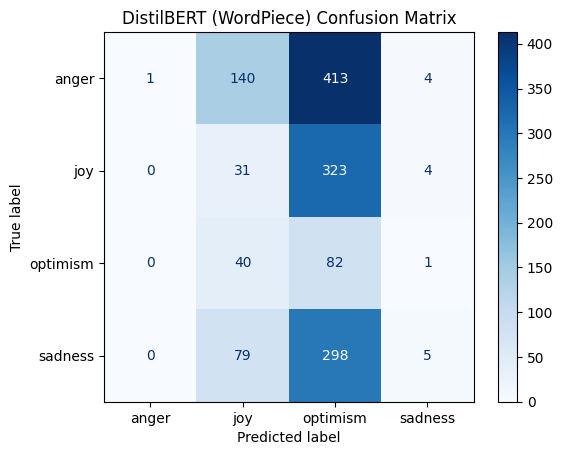

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = test_df['label'].map(id_labels)
y_pred_bert = test_df['distilbert_pred']
cm_bert = confusion_matrix(y_true, y_pred_bert, labels=candidate_labels)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=candidate_labels)
disp_bert.plot(cmap=plt.cm.Blues)
plt.title("DistilBERT (WordPiece) Confusion Matrix")
plt.show()

In [19]:
import pandas as pd
report_df = pd.DataFrame(results["DistilRoBERTa (BPE)"]["Classification Report Dict"]).transpose()
report_df

,precision,recall,f1-score,support
anger,0.343915,0.116487,0.174029,558.000000
joy,0.071429,0.030726,0.042969,358.000000
optimism,0.044693,0.065041,0.052980,123.000000
sadness,0.250278,0.589005,0.351288,382.000000
accuracy,0.217452,0.217452,0.217452,0.217452
macro avg,0.177579,0.200315,0.155317,1421.000000
weighted avg,0.224194,0.217452,0.178184,1421.000000


In [20]:
report_df.to_markdown()

'|              |   precision |    recall |   f1-score |     support |\n|:-------------|------------:|----------:|-----------:|------------:|\n| anger        |   0.343915  | 0.116487  |  0.174029  |  558        |\n| joy          |   0.0714286 | 0.0307263 |  0.0429688 |  358        |\n| optimism     |   0.0446927 | 0.0650407 |  0.0529801 |  123        |\n| sadness      |   0.250278  | 0.589005  |  0.351288  |  382        |\n| accuracy     |   0.217452  | 0.217452  |  0.217452  |    0.217452 |\n| macro avg    |   0.177579  | 0.200315  |  0.155317  | 1421        |\n| weighted avg |   0.224194  | 0.217452  |  0.178184  | 1421        |'

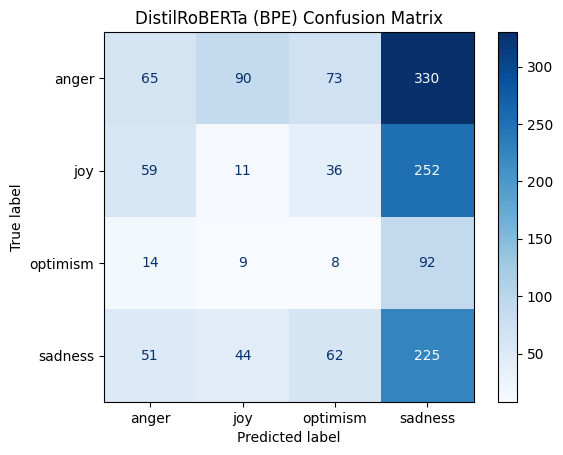

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = test_df['label'].map(id_labels)
y_pred_rob = test_df['distilroberta_pred']
cm_rob = confusion_matrix(y_true, y_pred_rob, labels=candidate_labels)
disp_rob = ConfusionMatrixDisplay(confusion_matrix=cm_rob, display_labels=candidate_labels)
disp_rob.plot(cmap=plt.cm.Blues)
plt.title("DistilRoBERTa (BPE) Confusion Matrix")
plt.show()

In [22]:
import pandas as pd
from analysis import show_tokenization

both_mis_df = test_df[
    (test_df['label'] != test_df['distilbert_pred'].map(labels_id)) &
    (test_df['label'] != test_df['distilroberta_pred'].map(labels_id))
].copy()

zero_shot_error_samples = both_mis_df.sample(8, random_state=15179996)

zero_shot_error_samples.to_csv("zero_shot_errors.csv", index=True)

print(f"Found {len(both_mis_df)} samples misclassified by both models in zero-shot.")
print("Displaying 8 samples with tokenization splits:\n")

for i, row in zero_shot_error_samples.iterrows():
    print(f"True Label: {id_labels[row['label']]}")
    print(f"DistilBERT pred: {row['distilbert_pred']}")
    print(f"DistilRoBERTa pred: {row['distilroberta_pred']}")
    print(f"Text: {row['text']}")

    tokens_data = show_tokenization(row['text'])
    for d in tokens_data:
        print(f"  {d['Tokenizer']} ({d['Model']}): {d['Tokens']}")
    print()

Found 1003 samples misclassified by both models in zero-shot.
Displaying 8 samples with tokenization splits:

True Label: optimism
DistilBERT pred: joy
DistilRoBERTa pred: sadness
Text: That morning when you get half-way to work and THEN realize the 4 year old is still in the back seat.  #backtrack
  WordPiece (DistilBERT): ['that', 'morning', 'when', 'you', 'get', 'half', '-', 'way', 'to', 'work', 'and', 'then', 'realize', 'the', '4', 'year', 'old', 'is', 'still', 'in', 'the', 'back', 'seat', '.', '#', 'back', '##tra', '##ck']
  BPE (DistilRoBERTa): ['That', 'Ġmorning', 'Ġwhen', 'Ġyou', 'Ġget', 'Ġhalf', '-', 'way', 'Ġto', 'Ġwork', 'Ġand', 'ĠTHEN', 'Ġrealize', 'Ġthe', 'Ġ4', 'Ġyear', 'Ġold', 'Ġis', 'Ġstill', 'Ġin', 'Ġthe', 'Ġback', 'Ġseat', '.', 'Ġ', 'Ġ#', 'back', 'track']

True Label: optimism
DistilBERT pred: joy
DistilRoBERTa pred: sadness
Text: There is much in the world to make us #afraid. There is much more in our faith to make us #unafraid.
  WordPiece (DistilBERT): ['there', 'is

In [23]:
import pandas as pd
from analysis import show_tokenization

both_mis_df = test_df[
    (test_df['label'] != test_df['distilbert_pred'].map(labels_id)) &
    (test_df['label'] != test_df['distilroberta_pred'].map(labels_id))
].copy()

zero_shot_error_samples = both_mis_df.sample(8, random_state=15179996)

zero_shot_error_samples.to_csv("zero_shot_errors.csv", index=True)

print(f"Found {len(both_mis_df)} samples misclassified by both models in zero-shot: \n")

for i, row in zero_shot_error_samples.iterrows():
    print(f"True Label: {id_labels[row['label']]}")
    print(f"DistilBERT pred: {row['distilbert_pred']}")
    print(f"DistilRoBERTa pred: {row['distilroberta_pred']}")
    print(f"Text: {row['text']}")

    tokens_data = show_tokenization(row['text'])
    for d in tokens_data:
        print(f"  {d['Tokenizer']} ({d['Model']}): {d['Tokens']}")
    print()

Found 1003 samples misclassified by both models in zero-shot: 

True Label: optimism
DistilBERT pred: joy
DistilRoBERTa pred: sadness
Text: That morning when you get half-way to work and THEN realize the 4 year old is still in the back seat.  #backtrack
  WordPiece (DistilBERT): ['that', 'morning', 'when', 'you', 'get', 'half', '-', 'way', 'to', 'work', 'and', 'then', 'realize', 'the', '4', 'year', 'old', 'is', 'still', 'in', 'the', 'back', 'seat', '.', '#', 'back', '##tra', '##ck']
  BPE (DistilRoBERTa): ['That', 'Ġmorning', 'Ġwhen', 'Ġyou', 'Ġget', 'Ġhalf', '-', 'way', 'Ġto', 'Ġwork', 'Ġand', 'ĠTHEN', 'Ġrealize', 'Ġthe', 'Ġ4', 'Ġyear', 'Ġold', 'Ġis', 'Ġstill', 'Ġin', 'Ġthe', 'Ġback', 'Ġseat', '.', 'Ġ', 'Ġ#', 'back', 'track']

True Label: optimism
DistilBERT pred: joy
DistilRoBERTa pred: sadness
Text: There is much in the world to make us #afraid. There is much more in our faith to make us #unafraid.
  WordPiece (DistilBERT): ['there', 'is', 'much', 'in', 'the', 'world', 'to', 'make',

In [24]:
import pandas as pd
test_df['label_str'] = test_df['label'].map(id_labels)

both_wrong = test_df[(test_df['distilbert_pred'] != test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)

bert_right_rob_wrong = test_df[(test_df['distilbert_pred'] == test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)

rob_right_bert_wrong = test_df[(test_df['distilroberta_pred'] == test_df['label_str']) & (test_df['distilbert_pred'] != test_df['label_str'])].head(8)

print(f"Both wrong: {len(both_wrong)}")
print(f"DistilBERT right, DistilRoBERTa wrong: {len(bert_right_rob_wrong)}")
print(f"DistilRoBERTa right, DistilBERT wrong: {len(rob_right_bert_wrong)}")

both_wrong_indices = both_wrong.index.tolist()
bert_right_rob_wrong_indices = bert_right_rob_wrong.index.tolist()
rob_right_bert_wrong_indices = rob_right_bert_wrong.index.tolist()


Both wrong: 8
DistilBERT right, DistilRoBERTa wrong: 8
DistilRoBERTa right, DistilBERT wrong: 8


In [25]:
from transformers import AutoTokenizer

tokenizer_bert = DistilBERT_zero_shot_pipeline.tokenizer
tokenizer_rob = DistilRoBERTa_zero_shot_pipeline.tokenizer

def analyze_tokenization(df, title):
    for idx, row in df.iterrows():
        text = row['text']
        true_label = row['label_str']
        pred_bert = row['distilbert_pred']
        pred_rob = row['distilroberta_pred']

        tokens_bert = tokenizer_bert.tokenize(text)
        tokens_rob = tokenizer_rob.tokenize(text)

        print(f"Text: {text}")
        print(f"True: {true_label} | DistilBERT Pred: {pred_bert} | DistilRoBERTa Pred: {pred_rob}")
        print(f"WordPiece (DistilBERT): {tokens_bert}")
        print(f"BPE (DistilRoBERTa): {tokens_rob}")

analyze_tokenization(both_wrong, "Misclassified by BOTH")
analyze_tokenization(bert_right_rob_wrong, "DistilBERT Right, DistilRoBERTa Wrong")
analyze_tokenization(rob_right_bert_wrong, "DistilRoBERTa Right, DistilBERT Wrong")


Text: @user Interesting choice of words... Are you confirming that governments fund #terrorism? Bit of an open door, but still...
True: anger | DistilBERT Pred: joy | DistilRoBERTa Pred: optimism
WordPiece (DistilBERT): ['@', 'user', 'interesting', 'choice', 'of', 'words', '.', '.', '.', 'are', 'you', 'confirming', 'that', 'governments', 'fund', '#', 'terrorism', '?', 'bit', 'of', 'an', 'open', 'door', ',', 'but', 'still', '.', '.', '.']
BPE (DistilRoBERTa): ['@', 'user', 'ĠInteresting', 'Ġchoice', 'Ġof', 'Ġwords', '...', 'ĠAre', 'Ġyou', 'Ġconfirming', 'Ġthat', 'Ġgovernments', 'Ġfund', 'Ġ#', 'terrorism', '?', 'ĠBit', 'Ġof', 'Ġan', 'Ġopen', 'Ġdoor', ',', 'Ġbut', 'Ġstill', '...']
Text: @user Welcome to #MPSVT! We are delighted to have you! #grateful #MPSVT #relationships
True: joy | DistilBERT Pred: optimism | DistilRoBERTa Pred: sadness
WordPiece (DistilBERT): ['@', 'user', 'welcome', 'to', '#', 'mps', '##v', '##t', '!', 'we', 'are', 'delighted', 'to', 'have', 'you', '!', '#', 'grateful

In [26]:
import json
with open("error_analysis_indices.json", "w") as f:
    json.dump({
        "both_wrong": both_wrong_indices,
        "bert_right_rob_wrong": bert_right_rob_wrong_indices,
        "rob_right_bert_wrong": rob_right_bert_wrong_indices
    }, f)
print("Saved indices to error_analysis_indices.json")


Saved indices to error_analysis_indices.json


In [1]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

from huggingface_hub import login
if HF_TOKEN:
    login(token=HF_TOKEN)

In [ ]:
import pandas as pd
from datasets import Dataset

In [5]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
labels_id = {"anger": 0, "joy": 1, "optimism": 2, "sadness": 3}
candidate_labels = list(id_labels.values())
hypothesis_template = "This tweet expresses {}."

In [6]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Training set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Testing set: {len(test_df)}")


README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Training set: 3257
Validation set: 374
Testing set: 1421


In [7]:
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [8]:
ft_results = {}

# Train DistilBERT Model

In [9]:
repo_id = "bdanko/bert-tweeteval"
ft_results["distilbert-base-uncased-tweeteval"] = train_and_evaluate(
    "distilbert-base-uncased",
    train_ds, val_ds, test_ds, test_df,
    "distilbert-base-uncased-tweeteval",
    candidate_labels,
    push_to_hub=True,
    hub_model_id=f"{repo_id}-distilbert"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...eeteval/training_args.bin: 100%|##########| 5.26kB / 5.26kB            

  ...eeteval/model.safetensors:  15%|#4        | 40.0MB /  268MB            

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Evaluating distilbert-base-uncased-tweeteval_StandardTest on provided dataset (size: 1421)...


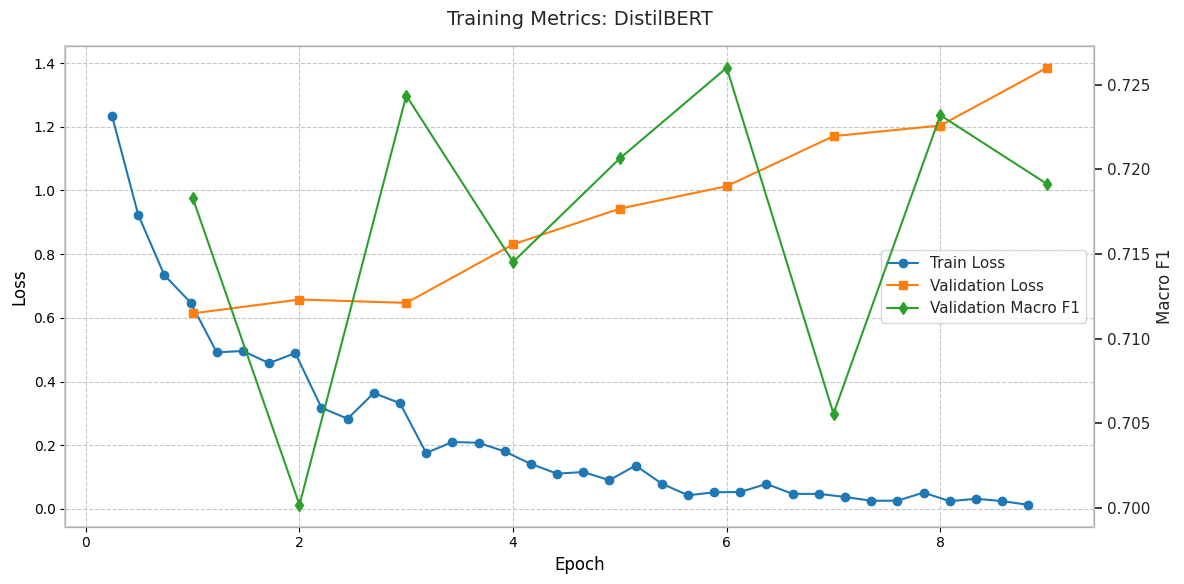

In [10]:
loss_plot(ft_results['distilbert-base-uncased-tweeteval'][0]['Log History'], 'DistilBERT')

# Train DistilRoBERTa Model

In [11]:
repo_id = "bdanko/bert-tweeteval"
ft_results["distilroberta-base-tweeteval"] = train_and_evaluate(
    "distilroberta-base",
    train_ds, val_ds, test_ds, test_df,
    "distilroberta-base-tweeteval",
    candidate_labels,
    push_to_hub=True,
    hub_model_id=f"{repo_id}-distilroberta"
)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...eeteval/training_args.bin: 100%|##########| 5.26kB / 5.26kB            

  ...eeteval/model.safetensors:  12%|#2        | 39.9MB /  328MB            

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

Evaluating distilroberta-base-tweeteval_StandardTest on provided dataset (size: 1421)...


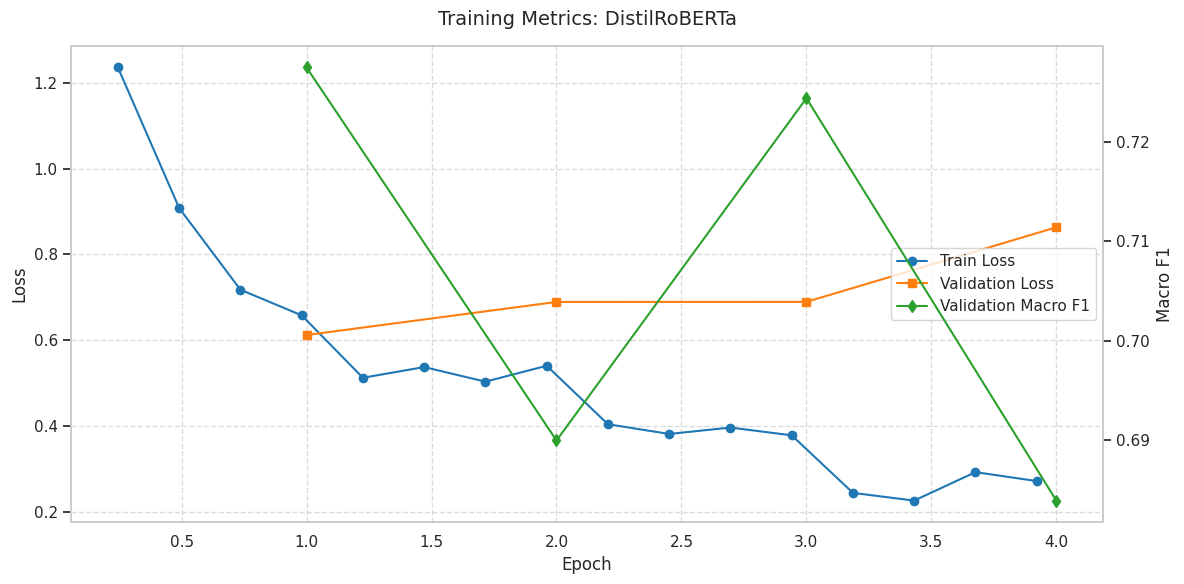

In [12]:
loss_plot(ft_results['distilroberta-base-tweeteval'][0]['Log History'], 'DistilRoBERTa')

In [13]:
final_df = pd.DataFrame({k: v[0] for k, v in ft_results.items()}).T
print(final_df[['Accuracy', 'Macro F1', 'ECE', 'Time/100']].to_string(
    formatters={'Accuracy': '{:,.2%}'.format, 'Macro F1': '{:,.2%}'.format,
                'ECE': '{:.4f}'.format, 'Time/100': '{:.2f}ms'.format}))

                                  Accuracy Macro F1     ECE Time/100
distilbert-base-uncased-tweeteval   79.80%   76.12%  0.1698  74.15ms
distilroberta-base-tweeteval        78.89%   75.06%  0.0421  98.87ms


In [14]:
final_dict = pd.DataFrame(ft_results["distilbert-base-uncased-tweeteval"][0]["Classification Report Dict"])
final_dict

,anger,joy,optimism,sadness,accuracy,macro avg,weighted avg
precision,0.840502,0.782723,0.657407,0.790885,0.79803,0.767879,0.796758
recall,0.840502,0.835196,0.577236,0.772251,0.79803,0.756296,0.798030
f1-score,0.840502,0.808108,0.614719,0.781457,0.79803,0.761196,0.796924
support,558.000000,358.000000,123.000000,382.000000,0.79803,1421.000000,1421.000000


In [15]:
final_dict.to_markdown()

'|           |      anger |        joy |   optimism |    sadness |   accuracy |   macro avg |   weighted avg |\n|:----------|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|---------------:|\n| precision |   0.840502 |   0.782723 |   0.657407 |   0.790885 |    0.79803 |    0.767879 |       0.796758 |\n| recall    |   0.840502 |   0.835196 |   0.577236 |   0.772251 |    0.79803 |    0.756296 |       0.79803  |\n| f1-score  |   0.840502 |   0.808108 |   0.614719 |   0.781457 |    0.79803 |    0.761196 |       0.796924 |\n| support   | 558        | 358        | 123        | 382        |    0.79803 | 1421        |    1421        |'

In [16]:
final_dict = pd.DataFrame(ft_results["distilroberta-base-tweeteval"][0]["Classification Report Dict"])
final_dict

,anger,joy,optimism,sadness,accuracy,macro avg,weighted avg
precision,0.787440,0.755668,0.833333,0.821752,0.788881,0.799548,0.792632
recall,0.876344,0.837989,0.487805,0.712042,0.788881,0.728545,0.788881
f1-score,0.829517,0.794702,0.615385,0.762973,0.788881,0.750644,0.784322
support,558.000000,358.000000,123.000000,382.000000,0.788881,1421.000000,1421.000000


In [17]:
final_dict.to_markdown()

'|           |      anger |        joy |   optimism |    sadness |   accuracy |   macro avg |   weighted avg |\n|:----------|-----------:|-----------:|-----------:|-----------:|-----------:|------------:|---------------:|\n| precision |   0.78744  |   0.755668 |   0.833333 |   0.821752 |   0.788881 |    0.799548 |       0.792632 |\n| recall    |   0.876344 |   0.837989 |   0.487805 |   0.712042 |   0.788881 |    0.728545 |       0.788881 |\n| f1-score  |   0.829517 |   0.794702 |   0.615385 |   0.762973 |   0.788881 |    0.750644 |       0.784322 |\n| support   | 558        | 358        | 123        | 382        |   0.788881 | 1421        |    1421        |'

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

<Figure size 600x600 with 0 Axes>

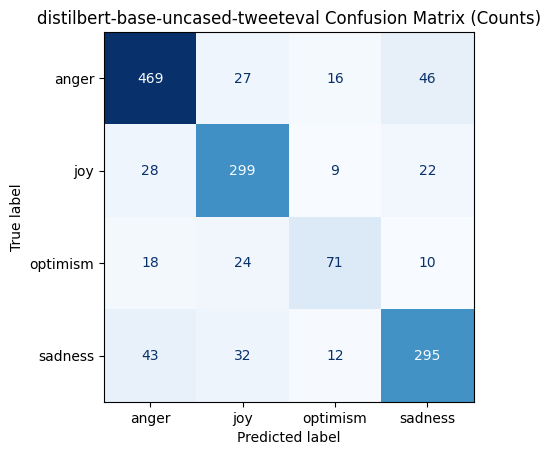

<Figure size 600x600 with 0 Axes>

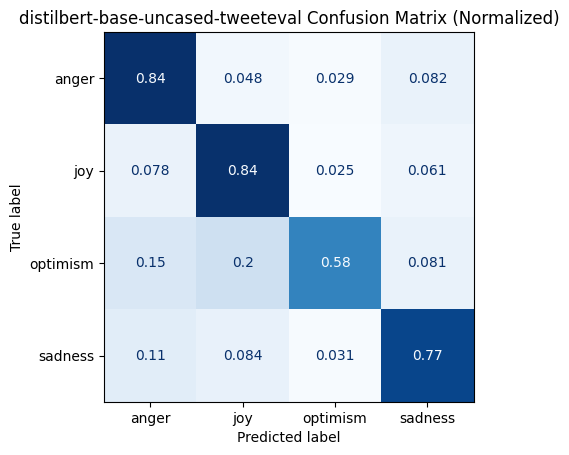

Map:   0%|          | 0/1421 [00:00<?, ? examples/s]

<Figure size 600x600 with 0 Axes>

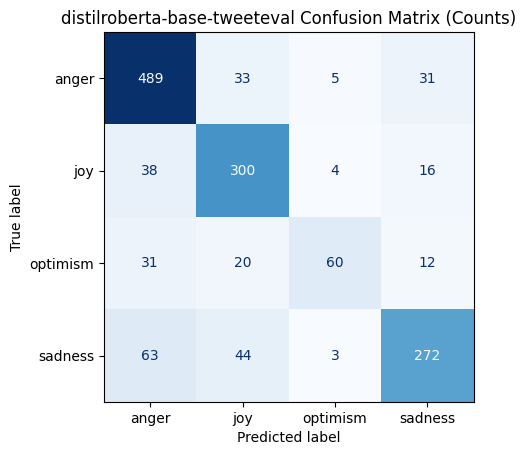

<Figure size 600x600 with 0 Axes>

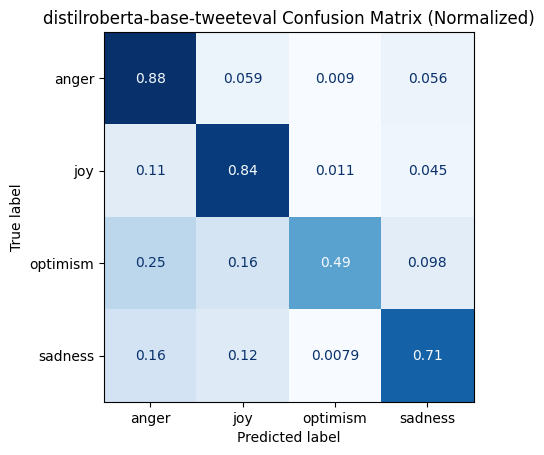

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.rcdefaults()
plt.style.use("default")
plt.rcParams["axes.grid"] = False

y_true = test_df["label"]
labels_list = list(id_labels.values())

for model_key, (_, trainer, tokenizer) in ft_results.items():

    tokenized_eval = test_ds.map(
        lambda x: tokenizer(x["text"], truncation=True, padding=True),
        batched=True
    )

    preds = trainer.predict(tokenized_eval).predictions
    y_pred = np.argmax(preds, axis=-1)

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    plt.figure(figsize=(6,6))
    ConfusionMatrixDisplay(cm, display_labels=labels_list).plot(cmap="Blues", colorbar=False)
    plt.grid(False)
    plt.title(f"{model_key} Confusion Matrix (Counts)")
    plt.show()

    plt.figure(figsize=(6,6))
    ConfusionMatrixDisplay(cm_norm, display_labels=labels_list).plot(cmap="Blues", colorbar=False)
    plt.grid(False)
    plt.title(f"{model_key} Confusion Matrix (Normalized)")
    plt.show()

In [ ]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

from huggingface_hub import login
if HF_TOKEN:
    login(token=HF_TOKEN)

In [4]:
from download import download_and_split_dataset
from train import train_and_evaluate

import pandas as pd
from datasets import Dataset

from corruption import create_corruption_ablations
from domain_shift import create_shift_ablation_sets
from transformers import Trainer, AutoModelForSequenceClassification, AutoTokenizer


In [5]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
labels_id = {"anger": 0, "joy": 1, "optimism": 2, "sadness": 3}
candidate_labels = list(id_labels.values())
hypothesis_template = "This tweet expresses {}."

In [6]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Training set: {len(train_df)}")
print(f"Validation set: {len(val_df)}")
print(f"Testing set: {len(test_df)}")

README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Training set: 3257
Validation set: 374
Testing set: 1421


In [7]:
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [8]:
ft_results = {}

In [10]:
import torch
import os
import sys

In [ ]:
from train import evaluate
import pandas as pd
from transformers import Trainer, AutoModelForSequenceClassification, AutoTokenizer
from corruption import create_corruption_ablations
from domain_shift import create_shift_ablation_sets

In [11]:
repo_id = "bdanko/bert-tweeteval"
model_names = [f"{repo_id}-distilbert", f"{repo_id}-distilroberta"]
ft_results = {}

for model_name in model_names:
    print(f"Evaluating model: {model_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    trainer = Trainer(model=model)

    ft_results[model_name] = {}

    # Baseline evaluation
    ft_results[model_name]["standard"] = evaluate(trainer, tokenizer, test_df, model_name, candidate_labels)

    # Corruption Ablations
    print(f"\nRunning corruption ablations for {model_name}")
    corrupted_dfs = create_corruption_ablations(test_df)
    ft_results[model_name]["corruptions"] = {}
    for name, c_df in corrupted_dfs.items():
        ft_results[model_name]["corruptions"][name] = evaluate(trainer, tokenizer, c_df, f"{model_name}_{name}", candidate_labels)

    # Domain Shift Ablations
    print(f"\nRunning domain shift ablations {model_name}")
    shift_dfs = create_shift_ablation_sets(test_df)
    ft_results[model_name]["shifts"] = {}
    for name, s_df in shift_dfs.items():
        ft_results[model_name]["shifts"][name] = evaluate(trainer, tokenizer, s_df, f"{model_name}_{name}", candidate_labels)


Evaluating model: bdanko/bert-tweeteval-distilbert


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Evaluating bdanko/bert-tweeteval-distilroberta_no_links on provided dataset (size: 1421)...


Map:   0%|          | 0/673 [00:00<?, ? examples/s]

Evaluating bdanko/bert-tweeteval-distilroberta_with_hashtags on provided dataset (size: 673)...


Map:   0%|          | 0/748 [00:00<?, ? examples/s]

Evaluating bdanko/bert-tweeteval-distilroberta_no_hashtags on provided dataset (size: 748)...


In [19]:
import pandas as pd

all_rows = []

for model_path, categories in ft_results.items():
    model_name = model_path.split('/')[-1]

    for cat_type in ["corruptions", "shifts"]:
        for test_name, res in categories.get(cat_type, {}).items():
            macro_avg = res['Classification Report Dict']['macro avg']
            all_rows.append({
                'Type': cat_type.capitalize(),
                'Test': test_name,
                'Model': model_name,
                'Accuracy': res['Accuracy'],
                'Macro F1': res['Macro F1'],
                'Macro Precision': macro_avg['precision'],
                'Macro Recall': macro_avg['recall'],
                'ECE': res['ECE']
            })

df = pd.DataFrame(all_rows)

unified_df = df.pivot_table(
    index=['Type', 'Test'],
    columns='Model',
    values=['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall', 'ECE']
)

unified_df = unified_df.swaplevel(0, 1, axis=1).sort_index(axis=1)

display(unified_df)


Model                           bert-tweeteval-distilbert                      \
                                                 Accuracy       ECE  Macro F1   
Type        Test                                                                
Corruptions corruption_all                       0.777621  0.186762  0.731208   
            corruption_emojis                    0.796622  0.169403  0.759471   
            corruption_hashtags                  0.797326  0.169666  0.758076   
            corruption_typos                     0.774806  0.192172  0.735679   
            original                             0.798030  0.169843  0.761196   
Shifts      full_test                            0.798030  0.169843  0.761196   
            no_hashtags                          0.779412  0.183594  0.729214   
            no_links                             0.798030  0.169843  0.761196   
            no_mentions                          0.786865  0.178595  0.764952   
            with_hashtags                        0.818722  0.155966  0.791053   
            with_mentions                        0.812704  0.158342  0.724186   

Model                                                         \
                                Macro Precision Macro Recall   
Type        Test                                               
Corruptions corruption_all             0.748215     0.719606   
            corruption_emojis          0.765310     0.754525   
            corruption_hashtags        0.767174     0.751265   
            corruption_typos           0.750336     0.726397   
            original                   0.767879     0.756296   
Shifts      full_test                  0.767879     0.756296   
            no_hashtags                0.740608     0.721849   
            no_links                   0.767879     0.756296   
            no_mentions                0.763810     0.766616   
            with_hashtags              0.795572     0.789115   
            with_mentions              0.761235     0.705813   

Model                           bert-tweeteval-distilroberta            \
                                                    Accuracy       ECE   
Type        Test                                                         
Corruptions corruption_all                          0.769880  0.027935   
            corruption_emojis                       0.788177  0.044574   
            corruption_hashtags                     0.790289  0.049607   
            corruption_typos                        0.762139  0.032455   
            original                                0.788881  0.042115   
Shifts      full_test                               0.788881  0.042115   
            no_hashtags                             0.783422  0.055099   
            no_links                                0.788881  0.042115   
            no_mentions                             0.788104  0.041246   
            with_hashtags                           0.794948  0.038689   
            with_mentions                           0.789902  0.046546   

Model                                                                   
                                 Macro F1 Macro Precision Macro Recall  
Type        Test                                                        
Corruptions corruption_all       0.729321        0.785784     0.704836  
            corruption_emojis    0.754264        0.799723     0.730673  
            corruption_hashtags  0.750437        0.804039     0.727826  
            corruption_typos     0.719843        0.767177     0.700259  
            original             0.750644        0.799548     0.728545  
Shifts      full_test            0.750644        0.799548     0.728545  
            no_hashtags          0.730822        0.795115     0.706223  
            no_links             0.750644        0.799548     0.728545  
            no_mentions          0.763955        0.796607     0.749939  
            with_hashtags        0.767394        0.8042

In [17]:
unified_df.to_markdown()

"|                                        |   ('bert-tweeteval-distilbert', 'Accuracy') |   ('bert-tweeteval-distilbert', 'ECE') |   ('bert-tweeteval-distilbert', 'Macro F1') |   ('bert-tweeteval-distilbert', 'Macro Precision') |   ('bert-tweeteval-distilbert', 'Macro Recall') |   ('bert-tweeteval-distilroberta', 'Accuracy') |   ('bert-tweeteval-distilroberta', 'ECE') |   ('bert-tweeteval-distilroberta', 'Macro F1') |   ('bert-tweeteval-distilroberta', 'Macro Precision') |   ('bert-tweeteval-distilroberta', 'Macro Recall') |\n|:---------------------------------------|--------------------------------------------:|---------------------------------------:|--------------------------------------------:|---------------------------------------------------:|------------------------------------------------:|-----------------------------------------------:|------------------------------------------:|-----------------------------------------------:|------------------------------------------------

In [1]:
import os
!git clone https://github.com/bencejdanko/bert-tweeteval

# ensure latest
os.chdir('/content/bert-tweeteval')
!cd /content/bert-tweeteval && git pull

Cloning into 'bert-tweeteval'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 206 (delta 131), reused 115 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (206/206), 794.59 KiB | 3.35 MiB/s, done.
Resolving deltas: 100% (131/131), done.
Already up to date.


In [2]:
# copy over package
PACKAGE = "src"

import sys
sys.path.append(f"/content/bert-tweeteval/{PACKAGE}")

In [3]:
import pandas as pd
import json
from transformers import AutoTokenizer, pipeline
from download import download_and_split_dataset

In [4]:
id_labels = {0: "anger", 1: "joy", 2: "optimism", 3: "sadness"}
train_df, val_df, test_df = download_and_split_dataset()
test_df['label_str'] = test_df['label'].map(id_labels)


README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

In [5]:
with open("/content/bert-tweeteval/src/error_analysis_indices.json", "r") as f:
    indices = json.load(f)
    both_wrong_zero = indices['both_wrong']
    bert_right_zero = indices['bert_right_rob_wrong']
    rob_right_zero = indices['rob_right_bert_wrong']
print("Loaded zero-shot error indices.")


Loaded zero-shot error indices.


In [6]:
model_bert_id = "bdanko/bert-tweeteval-distilbert"
model_rob_id = "bdanko/bert-tweeteval-distilroberta"

pipe_bert = pipeline("text-classification", model=model_bert_id)
pipe_rob = pipeline("text-classification", model=model_rob_id)

tokenizer_bert = AutoTokenizer.from_pretrained(model_bert_id)
tokenizer_rob = AutoTokenizer.from_pretrained(model_rob_id)


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/930 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
def predict_batch(texts, pipe):
    preds = pipe(texts, truncation=True, max_length=512)
    return [p['label'].lower() for p in preds]

print("Generating predictions...")
texts = test_df['text'].tolist()
test_df['distilbert_pred'] = predict_batch(texts, pipe_bert)
test_df['distilroberta_pred'] = predict_batch(texts, pipe_rob)

Generating predictions...


In [8]:
def print_sample_analysis(indices, title):
    if not indices:
        return
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")

    subset = test_df.loc[indices]
    for idx, row in subset.iterrows():
        text = row['text']
        true_label = row['label_str']
        pred_bert = row['distilbert_pred']
        pred_rob = row['distilroberta_pred']

        tokens_bert = tokenizer_bert.tokenize(text)
        tokens_rob = tokenizer_rob.tokenize(text)

        print(f"Text: {text}")
        print(f"True: {true_label} | Fine-Tuned DistilBERT Pred: {pred_bert} | Fine-Tuned DistilRoBERTa Pred: {pred_rob}")
        print(f"WordPiece (DistilBERT): {tokens_bert}")
        print(f"BPE (DistilRoBERTa): {tokens_rob}")
        print("-" * 50)

print_sample_analysis(both_wrong_zero, "Samples BOTH zero-shot models misclassified")
print_sample_analysis(bert_right_zero, "Samples zero-shot DistilBERT got right, but DistilRoBERTa missed")
print_sample_analysis(rob_right_zero, "Samples zero-shot DistilRoBERTa got right, but DistilBERT missed")



Samples BOTH zero-shot models misclassified
Text: @user Interesting choice of words... Are you confirming that governments fund #terrorism? Bit of an open door, but still...
True: anger | Fine-Tuned DistilBERT Pred: label_0 | Fine-Tuned DistilRoBERTa Pred: label_0
WordPiece (DistilBERT): ['@', 'user', 'interesting', 'choice', 'of', 'words', '.', '.', '.', 'are', 'you', 'confirming', 'that', 'governments', 'fund', '#', 'terrorism', '?', 'bit', 'of', 'an', 'open', 'door', ',', 'but', 'still', '.', '.', '.']
BPE (DistilRoBERTa): ['@', 'user', 'ĠInteresting', 'Ġchoice', 'Ġof', 'Ġwords', '...', 'ĠAre', 'Ġyou', 'Ġconfirming', 'Ġthat', 'Ġgovernments', 'Ġfund', 'Ġ#', 'terrorism', '?', 'ĠBit', 'Ġof', 'Ġan', 'Ġopen', 'Ġdoor', ',', 'Ġbut', 'Ġstill', '...']
--------------------------------------------------
Text: @user Welcome to #MPSVT! We are delighted to have you! #grateful #MPSVT #relationships
True: joy | Fine-Tuned DistilBERT Pred: label_1 | Fine-Tuned DistilRoBERTa Pred: label_1
WordPiece 

In [9]:
both_wrong_ft = test_df[(test_df['distilbert_pred'] != test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)
bert_right_rob_wrong_ft = test_df[(test_df['distilbert_pred'] == test_df['label_str']) & (test_df['distilroberta_pred'] != test_df['label_str'])].head(8)
rob_right_bert_wrong_ft = test_df[(test_df['distilroberta_pred'] == test_df['label_str']) & (test_df['distilbert_pred'] != test_df['label_str'])].head(8)

print_sample_analysis(both_wrong_ft.index.tolist(), "Misclassified by BOTH Fine-Tuned Models")
print_sample_analysis(bert_right_rob_wrong_ft.index.tolist(), "Fine-Tuned DistilBERT Right, DistilRoBERTa Wrong")
print_sample_analysis(rob_right_bert_wrong_ft.index.tolist(), "Fine-Tuned DistilRoBERTa Right, DistilBERT Wrong")



Misclassified by BOTH Fine-Tuned Models
Text: #Deppression is real. Partners w/ #depressed people truly dont understand the depth in which they affect us. Add in #anxiety &amp;makes it worse
True: sadness | Fine-Tuned DistilBERT Pred: label_3 | Fine-Tuned DistilRoBERTa Pred: label_3
WordPiece (DistilBERT): ['#', 'de', '##pp', '##ress', '##ion', 'is', 'real', '.', 'partners', 'w', '/', '#', 'depressed', 'people', 'truly', 'don', '##t', 'understand', 'the', 'depth', 'in', 'which', 'they', 'affect', 'us', '.', 'add', 'in', '#', 'anxiety', '&', 'amp', ';', 'makes', 'it', 'worse']
BPE (DistilRoBERTa): ['#', 'De', 'pp', 'ression', 'Ġis', 'Ġreal', '.', 'ĠPartners', 'Ġw', '/', 'Ġ#', 'dep', 'ressed', 'Ġpeople', 'Ġtruly', 'Ġdont', 'Ġunderstand', 'Ġthe', 'Ġdepth', 'Ġin', 'Ġwhich', 'Ġthey', 'Ġaffect', 'Ġus', '.', 'ĠAdd', 'Ġin', 'Ġ#', 'an', 'xiety', 'Ġ&', 'amp', ';', 'makes', 'Ġit', 'Ġworse']
--------------------------------------------------
Text: @user Interesting choice of words... Are you conf

In [5]:
import sys
import os
import pandas as pd
import getpass
import torch

from google.colab import userdata
openai_key = userdata.get('OPENROUTER_API_KEY')

In [6]:
!pip -q install backoff

In [7]:
!git clone https://github.com/bencejdanko/bert-tweeteval

sys.path.append(os.path.abspath('/content/bert-tweeteval/src'))

from download import download_and_split_dataset
from llm_eval import LLMEvaluator, PROMPT_1_MINIMAL, PROMPT_2_STRUCTURED, LABELS

Cloning into 'bert-tweeteval'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 206 (delta 131), reused 115 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (206/206), 794.59 KiB | 4.29 MiB/s, done.
Resolving deltas: 100% (131/131), done.


In [8]:
train_df, val_df, test_df = download_and_split_dataset()
print(f"Test set size: {len(test_df)}")

README.md: 0.00B [00:00, ?B/s]

emotion/train-00000-of-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

emotion/test-00000-of-00001.parquet:   0%|          | 0.00/105k [00:00<?, ?B/s]

emotion/validation-00000-of-00001.parque(…):   0%|          | 0.00/28.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]

Test set size: 1421


In [9]:
evaluator_qwen = LLMEvaluator(hf_model_name="Qwen/Qwen3-4B-Instruct-2507")
evaluator_qwen.load_hf_model()

Loading HF model: Qwen/Qwen3-4B-Instruct-2507 on cuda...


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

In [10]:
res_qwen_p1 = evaluator_qwen.evaluate(test_df, "hf", PROMPT_1_MINIMAL)


Evaluating hf (Batch size 100):   0%|          | 0/15 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

Evaluating hf (Batch size 100): 100%|██████████| 15/15 [00:35<00:00,  2.35s/it]


In [11]:
res_qwen_p2 = evaluator_qwen.evaluate(test_df, "hf", PROMPT_2_STRUCTURED)


Evaluating hf (Batch size 100): 100%|██████████| 15/15 [01:09<00:00,  4.61s/it]


In [12]:
evaluator_openai = LLMEvaluator(openai_api_key=openai_key)

In [13]:
res_gpt_p1 = evaluator_openai.evaluate(test_df, "openai", PROMPT_1_MINIMAL)


Evaluating openai (Batch size 100): 100%|██████████| 15/15 [01:10<00:00,  4.70s/it]


In [14]:
res_gpt_p2 = evaluator_openai.evaluate(test_df, "openai", PROMPT_2_STRUCTURED)


Evaluating openai (Batch size 100): 100%|██████████| 15/15 [00:53<00:00,  3.57s/it]


In [15]:
results = {
    "GPT-4o-mini (Minimal)": res_gpt_p1,
    "GPT-4o-mini (Structured)": res_gpt_p2,
    "Qwen3-4B-Instruct-2507 (Minimal)": res_qwen_p1,
    "Qwen3-4B-Instruct-2507 (Structured)": res_qwen_p2
}

comparison_df = pd.DataFrame({
    k: {m: v[m] for m in ["Accuracy", "Macro-F1", "Time_per_100"]}
    for k, v in results.items()
}).transpose()

comparison_df

,Accuracy,Macro-F1,Time_per_100
GPT-4o-mini (Minimal),0.800141,0.601466,5060.112734
GPT-4o-mini (Structured),0.821956,0.781499,3823.308211
Qwen3-4B-Instruct-2507 (Minimal),0.751583,0.584864,2571.471757
Qwen3-4B-Instruct-2507 (Structured),0.812104,0.758003,4931.231370


In [16]:
comparison_df.to_markdown()

'|                                     |   Accuracy |   Macro-F1 |   Time_per_100 |\n|:------------------------------------|-----------:|-----------:|---------------:|\n| GPT-4o-mini (Minimal)               |   0.800141 |   0.601466 |        5060.11 |\n| GPT-4o-mini (Structured)            |   0.821956 |   0.781499 |        3823.31 |\n| Qwen3-4B-Instruct-2507 (Minimal)    |   0.751583 |   0.584864 |        2571.47 |\n| Qwen3-4B-Instruct-2507 (Structured) |   0.812104 |   0.758003 |        4931.23 |'

In [17]:
from datasets import Dataset
import huggingface_hub

hf_token = userdata.get('HF_TOKEN')
huggingface_hub.login(token=hf_token)

predictions_data = {
    'True_Labels': results["GPT-4o-mini (Minimal)"]["True_Labels"]
}
for k, v in results.items():
    predictions_data[k] = v["Predictions"]

predictions_dataset = Dataset.from_dict(predictions_data)
predictions_dataset.push_to_hub('bdanko/tweeteval-llm-evaluation-predictions')

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 5.99kB / 5.99kB            

CommitInfo(commit_url='https://huggingface.co/datasets/bdanko/tweeteval-llm-evaluation-predictions/commit/da1e6c575ae766cdb7f2dc7262d4287684689038', commit_message='Upload dataset', commit_description='', oid='da1e6c575ae766cdb7f2dc7262d4287684689038', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/bdanko/tweeteval-llm-evaluation-predictions', endpoint='https://huggingface.co', repo_type='dataset', repo_id='bdanko/tweeteval-llm-evaluation-predictions'), pr_revision=None, pr_num=None)

In [18]:
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score

ds = load_dataset("bdanko/tweeteval-llm-evaluation-predictions", split="train")

model_names = [
    "GPT-4o-mini (Minimal)",
    "GPT-4o-mini (Structured)",
    "Qwen3-4B-Instruct-2507 (Minimal)",
    "Qwen3-4B-Instruct-2507 (Structured)",
]

results = {}
for name in model_names:
    y_true = ds["True_Labels"]
    y_pred = ds[name]
    results[name] = {
        "True_Labels":  y_true,
        "Predictions":  y_pred,
        "Accuracy":     accuracy_score(y_true, y_pred),
        "Macro-F1":     f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Time_per_100": None,  # not stored — would need re-inference to recover
    }


README.md:   0%|          | 0.00/502 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.99k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1421 [00:00<?, ? examples/s]

In [19]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

extended_rows = {}
for name, res in results.items():
    y_true = res['True_Labels']
    y_pred = res['Predictions']
    extended_rows[name] = {
        'Accuracy':        res['Accuracy'],
        'Macro-F1':        res['Macro-F1'],
        'Macro-Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro-Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Time_per_100':    res['Time_per_100'],
    }

extended_df = pd.DataFrame(extended_rows).transpose()
print(extended_df.to_markdown())
extended_df


|                                     |   Accuracy |   Macro-F1 |   Macro-Precision |   Macro-Recall |   Time_per_100 |
|:------------------------------------|-----------:|-----------:|------------------:|---------------:|---------------:|
| GPT-4o-mini (Minimal)               |   0.800141 |   0.601466 |          0.653766 |       0.579754 |            nan |
| GPT-4o-mini (Structured)            |   0.821956 |   0.781499 |          0.791218 |       0.773544 |            nan |
| Qwen3-4B-Instruct-2507 (Minimal)    |   0.751583 |   0.584864 |          0.594974 |       0.581751 |            nan |
| Qwen3-4B-Instruct-2507 (Structured) |   0.812104 |   0.758003 |          0.793805 |       0.741873 |            nan |


,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,Time_per_100
GPT-4o-mini (Minimal),0.800141,0.601466,0.653766,0.579754,NaN
GPT-4o-mini (Structured),0.821956,0.781499,0.791218,0.773544,NaN
Qwen3-4B-Instruct-2507 (Minimal),0.751583,0.584864,0.594974,0.581751,NaN
Qwen3-4B-Instruct-2507 (Structured),0.812104,0.758003,0.793805,0.741873,NaN


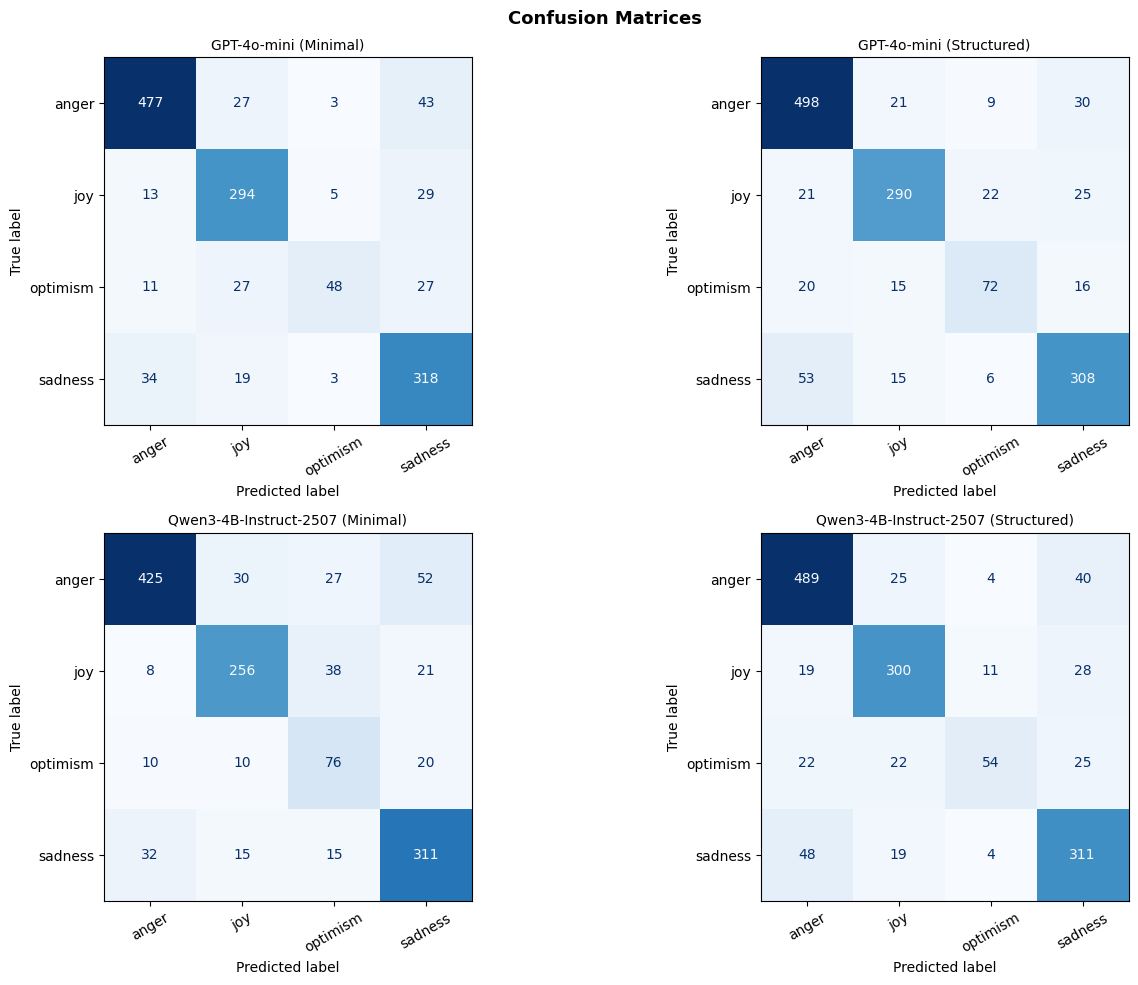

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

label_names = ['anger', 'joy', 'optimism', 'sadness']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res['True_Labels'], res['Predictions'], labels=label_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis='x', labelrotation=30)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
!pip install -q huggingface_hub datasets torch tqdm

In [12]:
import os
import sys
import torch
import json
import pickle
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, hf_hub_download

In [7]:
import os
import sys
current_dir = os.getcwd()
src_path = os.path.join(current_dir, 'src') if 'src' in os.listdir() else os.path.join(current_dir, 'n-gram-modeling', 'src')
sys.path.append(src_path)
print(f"added to path: {src_path}")

fatal: destination path 'n-gram-modeling' already exists and is not an empty directory.
Already up to date.


In [8]:
from data import get_jefferson_text, preprocess, build_vocab, TrigramDataset
from models import CountTrigramModel, NeuralTrigramModel
from train import train_neural_model
from decode import generate_greedy, generate_top_k, generate_nucleus, generate_beam_search
from eval import calculate_perplexity_count, calculate_perplexity_neural, get_text_perplexity

In [ ]:
text = get_jefferson_text()
tokens = preprocess(text)

# Split into train and test
split_idx = int(len(tokens) * 0.9)
train_tokens = tokens[:split_idx]
test_tokens = tokens[split_idx:]

vocab, word2idx, idx2word = build_vocab(train_tokens)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")
print(f"Train tokens: {len(train_tokens)}")
print(f"Test tokens: {len(test_tokens)}")

Loading Thomas Jefferson speeches...


data/state_ofthe_union_texts.jsonl:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/219 [00:00<?, ? examples/s]

Vocab size: 15031
Train tokens: 279502
Test tokens: 31056


In [10]:
train_idx = [word2idx[w] for w in train_tokens]
test_idx = [word2idx[w] for w in test_tokens if w in word2idx]

count_model = CountTrigramModel(vocab_size=vocab_size, add_k=0.1)
count_model.train(train_idx)

ppl_count = calculate_perplexity_count(count_model, test_idx)
print(f"Count Model Test Perplexity: {ppl_count:.4f}")

Count Model Test Perplexity: 7788.0915


In [13]:
train_dataset = TrigramDataset(train_tokens, word2idx)
val_split = int(len(train_dataset) * 0.9)
train_ds, val_ds = torch.utils.data.random_split(train_dataset, [val_split, len(train_dataset) - val_split])
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
nn_model = NeuralTrigramModel(vocab_size=vocab_size, embed_size=64, hidden_size=128)
nn_model = train_neural_model(nn_model, train_loader, val_loader, epochs=50, patience=5, lr=1e-3, device=device)

test_dataset = TrigramDataset([w for w in test_tokens if w in word2idx], word2idx)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
ppl_nn = calculate_perplexity_neural(nn_model, test_loader, device=device)
print(f"Neural Model Test Perplexity: {ppl_nn:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ks = [0.001, 0.01, 0.1, 0.5, 1.0]
perplexities = []

for k in ks:
    m = CountTrigramModel(vocab_size=vocab_size, add_k=k)
    m.train(train_idx)
    ppl = calculate_perplexity_count(m, test_idx)
    perplexities.append(ppl)
    print(f"k={k:.3f}, Perplexity: {ppl:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(ks, perplexities, marker='o', linestyle='-', color='#6366f1', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Smoothing Parameter (k)', fontsize=12)
plt.ylabel('Test Perplexity', fontsize=12)
plt.title('Ablation Study: smoothing effect on perplexity', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:
# Save Neural Model
torch.save(nn_model.state_dict(), 'nn_model.pth')

# Save Count Model (using pickle to preserve defaultdict structure)
with open('count_model.pkl', 'wb') as f:
    pickle.dump(count_model, f)

# Save Vocab
with open('vocab.json', 'w') as f:
    json.dump({'word2idx': word2idx, 'idx2word': {str(k): v for k, v in idx2word.items()}}, f)

print("Models and vocab saved locally.")

Models and vocab saved locally.


In [15]:
repo_id = "bdanko/n-gram-modeling"
api = HfApi()

files_to_upload = ["nn_model.pth", "count_model.pkl", "vocab.json"]

for filename in files_to_upload:
    try:
        api.upload_file(
            path_or_fileobj=filename,
            path_in_repo=filename,
            repo_id=repo_id
        )
        print(f"Uploaded {filename} to {repo_id}")
    except Exception as e:
        print(f"Failed to upload {filename}: {e}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  nn_model.pth                :   5%|4         |  581kB / 11.7MB            

Uploaded nn_model.pth to bdanko/n-gram-modeling


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  count_model.pkl             :  91%|#########1| 3.64MB / 3.99MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded count_model.pkl to bdanko/n-gram-modeling
Uploaded vocab.json to bdanko/n-gram-modeling


In [ ]:
hf_nn_path = hf_hub_download(repo_id=repo_id, filename="nn_model.pth")
hf_count_path = hf_hub_download(repo_id=repo_id, filename="count_model.pkl")
hf_vocab_path = hf_hub_download(repo_id=repo_id, filename="vocab.json")

with open(hf_vocab_path, 'r') as f:
    hf_vocab_data = json.load(f)
    hf_word2idx = hf_vocab_data['word2idx']
    hf_idx2word = {int(k): v for k, v in hf_vocab_data['idx2word'].items()}

# Load Neural Model
loaded_nn_model = NeuralTrigramModel(vocab_size=len(hf_word2idx))
loaded_nn_model.load_state_dict(torch.load(hf_nn_path, weights_only=True))
loaded_nn_model.eval()

# Load Count Model
with open(hf_count_path, 'rb') as f:
    loaded_count_model = pickle.load(f)

print("Models loaded successfully from HF.")

nn_model.pth:   0%|          | 0.00/11.7M [00:00<?, ?B/s]

count_model.pkl:   0%|          | 0.00/3.99M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Models loaded successfully from HF.


In [ ]:
w1_word, w2_word = "another", "year"
w1, w2 = hf_word2idx[w1_word], hf_word2idx[w2_word]
seed_text = f"{w1_word} {w2_word}"

strategies = [
    ("Greedy", generate_greedy, {}),
    ("Beam Search (w=3)", generate_beam_search, {"beam_width": 3}),
    ("Top-K (K=5)", generate_top_k, {"k": 5}),
    ("Nucleus (p=0.9)", generate_nucleus, {"p": 0.9})
]

models_to_test = [
    ("Count-based Trigram Model", loaded_count_model),
    ("Neural Trigram Model", loaded_nn_model)
]

for name, model in models_to_test:
    print(f"\n{'='*20} {name} {'='*20}")
    for strat_name, func, kwargs in strategies:
        generated = func(model, w1, w2, hf_word2idx, hf_idx2word, num_words=80, **kwargs)
        ppl = get_text_perplexity(model, generated, hf_word2idx)
        print(f"\n[{strat_name}] (Perplexity: {ppl:.2f})")
        print(generated)



Evaluating Count-based Trigram Model

Greedy
fellow citizens in the treasury on the part of the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the united states and the

Beam Search (width=3)
fellow citizens in the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and of the united states and

Top-K Sampling (K=5)
fellow citizens in cuba and puerto rico and an